In [1]:
!pip install yfinance

In [4]:
!pip install dtaidistance

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 12.9 MB/s eta 0:00:00


In [7]:
# Importing necessary packages
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

In [10]:
# Importing tick data from COKE and PEP
ticker1 = yf.download('COKE', start='2020-01-01', end ='2024-12-31')
ticker2 = yf.download('PEP', start='2020-01-01', end ='2024-12-31')

# Extracting only Adjusted Close prices
coke_close = ticker1['Close']
pep_close = ticker2['Close']

# Drop any NaN values
coke_close = coke_close.dropna()
pep_close = pep_close.dropna()

# Align both series to same trading day
combined = pd.concat([coke_close, pep_close], axis=1).dropna()
combined.columns = ['COKE','PEP']

print(combined.shape)
print(combined.head)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1257, 2)
<bound method NDFrame.head of                   COKE         PEP
Date                              
2020-01-02   26.822586  112.112373
2020-01-03   27.141729  111.955566
2020-01-06   26.785545  112.384796
2020-01-07   26.514849  110.618324
2020-01-08   26.334385  111.187881
...                ...         ...
2024-12-23  117.523239  144.188339
2024-12-24  119.361160  145.637009
2024-12-26  120.954750  145.284378
2024-12-27  121.912300  145.713242
2024-12-30  122.660126  144.598190

[1257 rows x 2 columns]>


In [11]:
# Z-score normalization
coke_norm = (combined['COKE'] - combined['COKE'].mean()) / combined['COKE'].std()
pep_norm = (combined['PEP'] - combined['PEP'].mean()) / combined['PEP'].std()

print(coke_norm.describe())
print(pep_norm.describe())

count    1.257000e+03
mean     4.522149e-17
std      1.000000e+00
min     -1.219410e+00
25%     -8.904160e-01
50%     -2.290225e-01
75%      3.424409e-01
max      2.630041e+00
Name: COKE, dtype: float64
count    1.257000e+03
mean     1.808860e-16
std      1.000000e+00
min     -2.869333e+00
25%     -1.001706e+00
50%      3.669123e-01
75%      7.925421e-01
max      1.737594e+00
Name: PEP, dtype: float64


In [12]:
# Verify Alignment
print(f'COKE length: {len(coke_norm)}')
print(f'PEP length: {len(pep_norm)}')
print(f'Same length: {len(coke_norm) == len(pep_norm)}')
print(f'Date range: {combined.index[0]} to {combined.index[-1]}')

COKE length: 1257
PEP length: 1257
Same length: True
Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00


In [13]:
# Compute DTW distance
coke_array = coke_norm.to_numpy()
pep_array = pep_norm.to_numpy()

distance = dtw.distance(coke_array, pep_array)
print(f'DTW distance between COKE and PEP: {distance:.4f}')

DTW distance between COKE and PEP: 18.1058


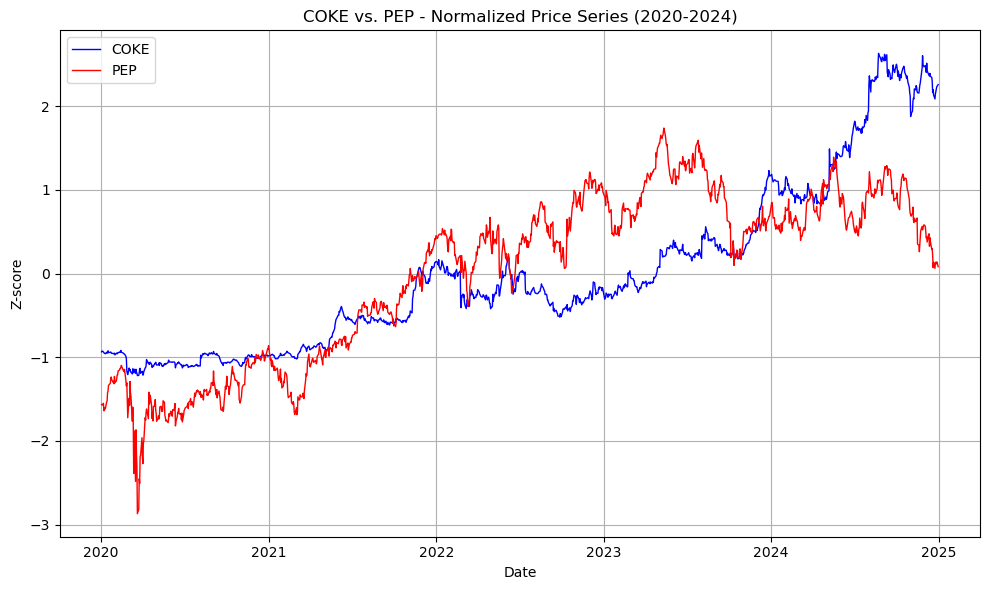

In [15]:
# Plot normalized price series 
plt.figure(figsize=(10,6))
plt.plot(combined.index, coke_norm, label='COKE', color='blue', linewidth=1)
plt.plot(combined.index, pep_norm, label='PEP', color='red', linewidth=1)
plt.title('COKE vs. PEP - Normalized Price Series (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Z-score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

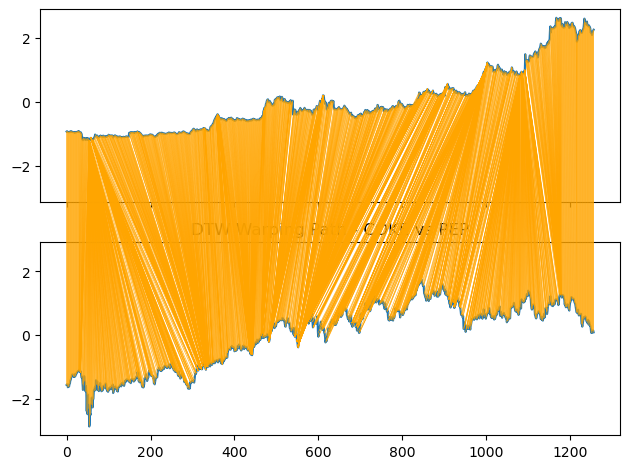

In [17]:
path = dtw.warping_path(coke_array, pep_array)
fig, ax = dtwvis.plot_warping(coke_array, pep_array, path)
plt.title("DTW Warping Path - COKE vs PEP")
plt.tight_layout()
plt.show()